In [2]:
import pandas as pd

df=pd.read_csv("C:\\Users\\swara\\Downloads\\Yewale_Amruttulya_Tea_Sales_Dataset.csv")

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Invoice_ID     15000 non-null  object
 1   Date           15000 non-null  object
 2   Time           15000 non-null  object
 3   Branch         15000 non-null  object
 4   Product        15000 non-null  object
 5   Category       15000 non-null  object
 6   Quantity       15000 non-null  int64 
 7   Unit Price     15000 non-null  int64 
 8   Cost Price     15000 non-null  int64 
 9   Revenue        15000 non-null  int64 
 10  Profit         15000 non-null  int64 
 11  Payment Mode   15000 non-null  object
 12  Customer Type  15000 non-null  object
 13  Employee       15000 non-null  object
dtypes: int64(5), object(9)
memory usage: 1.6+ MB


In [9]:
df.head()

,Invoice_ID,Date,Time,Branch,Product,Category,Quantity,Unit Price,Cost Price,Revenue,Profit,Payment Mode,Customer Type,Employee
0,INV00001,11/6/2025,9:25,Nagpur,Black Tea,Tea,3,18,9,54,27,UPI,New,Emp_13
1,INV00002,2/10/2025,14:21,Nagpur,Cream Roll,Snacks,4,25,12,100,52,UPI,Regular,Emp_12
2,INV00003,10/26/2025,21:24,Mumbai,Lemon Tea,Tea,1,22,11,22,11,UPI,New,Emp_11
3,INV00004,11/12/2025,18:48,Pune,Ginger Tea,Tea,3,20,10,60,30,Card,Regular,Emp_7
4,INV00005,8/7/2025,17:47,Indore,Rose Milk,Milk,4,45,28,180,68,UPI,New,Emp_17


In [10]:
### DATA CLEANING

df.isnull()

,Invoice_ID,Date,Time,Branch,Product,Category,Quantity,Unit Price,Cost Price,Revenue,Profit,Payment Mode,Customer Type,Employee
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,False,False,False,False,False,False,False,False,False,False,False,False,False,False
14996,False,False,False,False,False,False,False,False,False,False,False,False,False,False
14997,False,False,False,False,False,False,False,False,False,False,False,False,False,False
14998,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [11]:
df.isnull().sum()

Invoice_ID       0
Date             0
Time             0
Branch           0
Product          0
Category         0
Quantity         0
Unit Price       0
Cost Price       0
Revenue          0
Profit           0
Payment Mode     0
Customer Type    0
Employee         0
dtype: int64

In [12]:
df.isna().sum()

Invoice_ID       0
Date             0
Time             0
Branch           0
Product          0
Category         0
Quantity         0
Unit Price       0
Cost Price       0
Revenue          0
Profit           0
Payment Mode     0
Customer Type    0
Employee         0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [16]:
round(df.describe(),1)

,Quantity,Unit Price,Cost Price,Revenue,Profit
count,15000.0,15000.0,15000.0,15000.0,15000.0
mean,3.5,30.1,16.6,105.5,47.6
std,1.7,12.3,7.9,69.8,28.9
min,1.0,15.0,8.0,15.0,7.0
25%,2.0,20.0,10.0,50.0,25.0
50%,4.0,25.0,13.0,90.0,44.0
75%,5.0,35.0,20.0,140.0,65.0
max,6.0,60.0,35.0,360.0,150.0


In [9]:
#### FEATURE ENGINEERING

df['Date']=pd.to_datetime(df['Date'])

df['Month']=df['Date'].dt.month_name()

df['Year']=df['Date'].dt.year

df['Hour']=pd.to_datetime(df['Time']).dt.hour

df['Weekday']=df['Date'].dt.day_name()

df.head()


C:\Users\swara\AppData\Local\Temp\ipykernel_29512\2334904626.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Hour']=pd.to_datetime(df['Time']).dt.hour


,Invoice_ID,Date,Time,Branch,Product,Category,Quantity,Unit Price,Cost Price,Revenue,Profit,Payment Mode,Customer Type,Employee,Month,Year,Hour,Weekday
0,INV00001,2025-11-06,9:25,Nagpur,Black Tea,Tea,3,18,9,54,27,UPI,New,Emp_13,November,2025,9,Thursday
1,INV00002,2025-02-10,14:21,Nagpur,Cream Roll,Snacks,4,25,12,100,52,UPI,Regular,Emp_12,February,2025,14,Monday
2,INV00003,2025-10-26,21:24,Mumbai,Lemon Tea,Tea,1,22,11,22,11,UPI,New,Emp_11,October,2025,21,Sunday
3,INV00004,2025-11-12,18:48,Pune,Ginger Tea,Tea,3,20,10,60,30,Card,Regular,Emp_7,November,2025,18,Wednesday
4,INV00005,2025-08-07,17:47,Indore,Rose Milk,Milk,4,45,28,180,68,UPI,New,Emp_17,August,2025,17,Thursday


In [13]:
### Exploratory Data Analysis (EDA)

df['Revenue'].sum()


np.int64(1582827)

In [14]:
df.groupby('Month')['Revenue'].sum()


Month
April        125059
August       132220
December     138141
February     122652
January      140157
July         138584
June         128232
March        131285
May          131918
November     132542
October      128849
September    133188
Name: Revenue, dtype: int64

In [15]:
df.groupby('Branch')['Revenue'].sum()

Branch
Indore    317232
Mumbai    308855
Nagpur    322453
Nashik    317194
Pune      317093
Name: Revenue, dtype: int64

In [16]:
df.groupby('Category')['Revenue'].sum()

Category
Coffee    403920
Milk      330175
Snacks    444275
Tea       404457
Name: Revenue, dtype: int64

In [17]:

df.groupby('Product')['Quantity'].sum()

Product
Bakarwadi      4087
Black Tea      4066
Cake           4033
Cold Coffee    4112
Cookies        4013
Cream Roll     4010
Ginger Tea     4026
Hot Coffee     3930
Jaggery Tea    4111
Lemon Tea      4112
Masala Milk    4274
Regular Tea    3834
Rose Milk      4013
Name: Quantity, dtype: int64

In [18]:

df['Payment Mode'].value_counts()

Payment Mode
UPI     9906
Cash    2869
Card    2225
Name: count, dtype: int64

In [22]:

df['Customer Type'].value_counts()

Customer Type
Regular    9071
New        5929
Name: count, dtype: int64

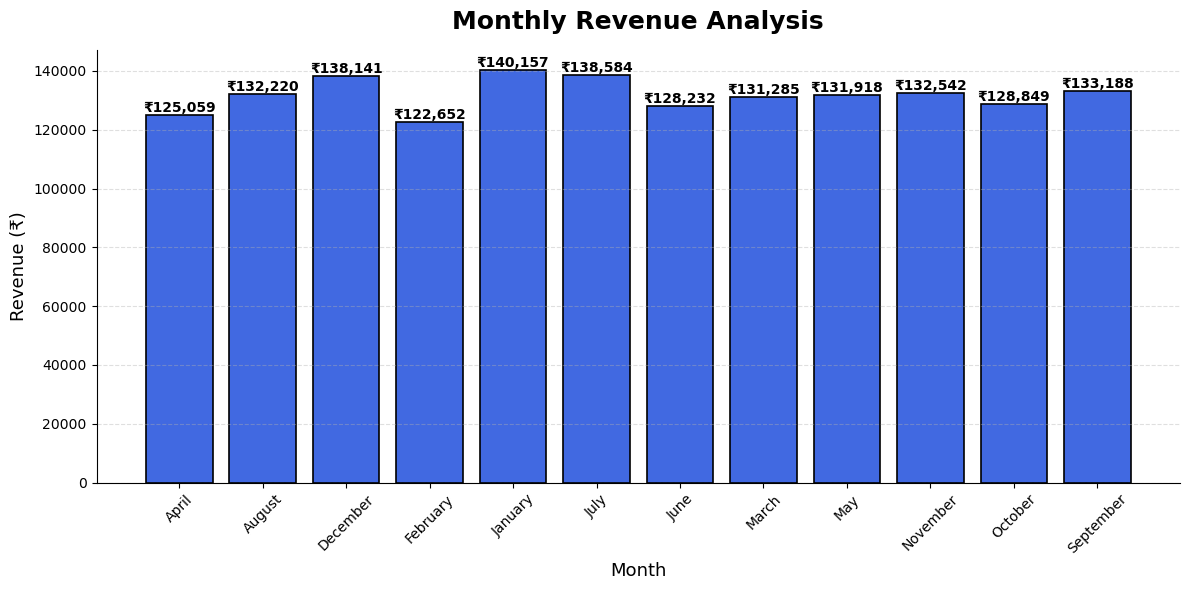

In [24]:
#### VISUALIZATION
# 1) Monthly Revenue Analysis

import matplotlib.pyplot as plt

# Aggregate revenue by month
monthly = df.groupby('Month')['Revenue'].sum()

# Sort months if needed
# monthly = monthly.reindex(['Jan','Feb','Mar','Apr','May','Jun',
#                            'Jul','Aug','Sep','Oct','Nov','Dec'])

plt.figure(figsize=(12, 6))

bars = plt.bar(
    monthly.index,
    monthly.values,
    color='royalblue',
    edgecolor='black',
    linewidth=1.2
)

# Title and labels
plt.title('Monthly Revenue Analysis', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=13)
plt.ylabel('Revenue (₹)', fontsize=13)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Remove top and right borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Rotate x-axis labels
plt.xticks(rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'₹{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

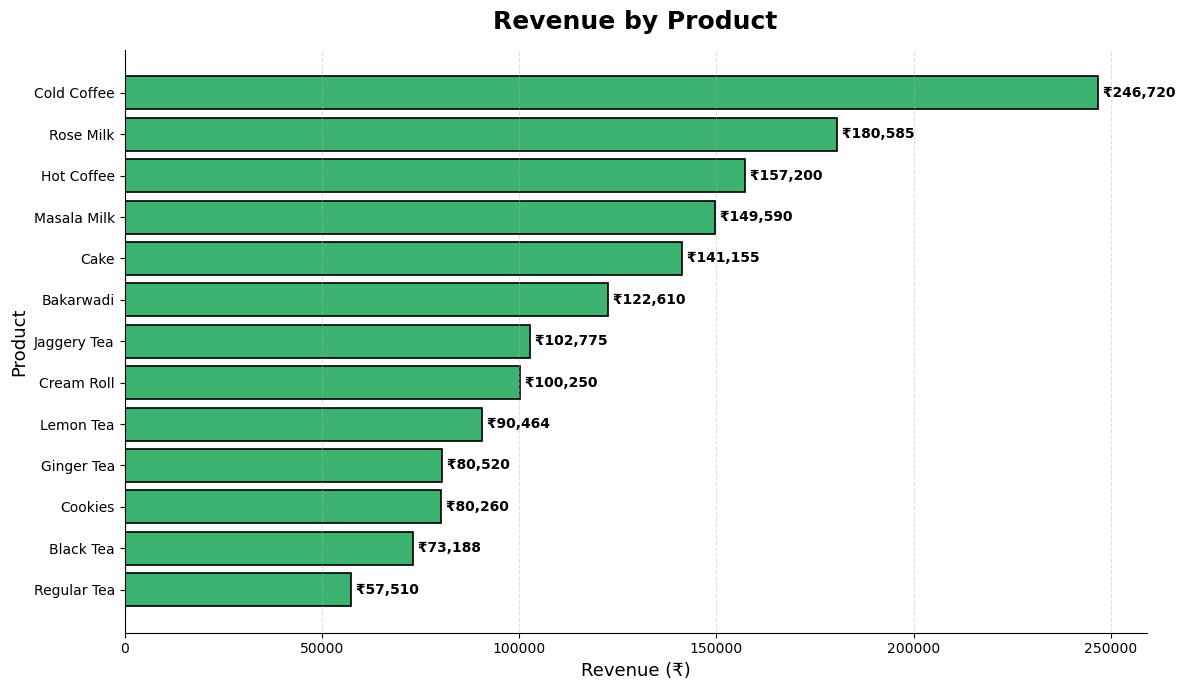

In [25]:
# 2) Revenue by Product

import matplotlib.pyplot as plt
product = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    product.index,
    product.values,
    color='mediumseagreen',
    edgecolor='black',
    linewidth=1.2
)

# Title and labels
plt.title('Revenue by Product', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Revenue (₹)', fontsize=13)
plt.ylabel('Product', fontsize=13)

# Grid
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Remove unnecessary borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Highest revenue at the top
plt.gca().invert_yaxis()

# Add revenue labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f' ₹{width:,.0f}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

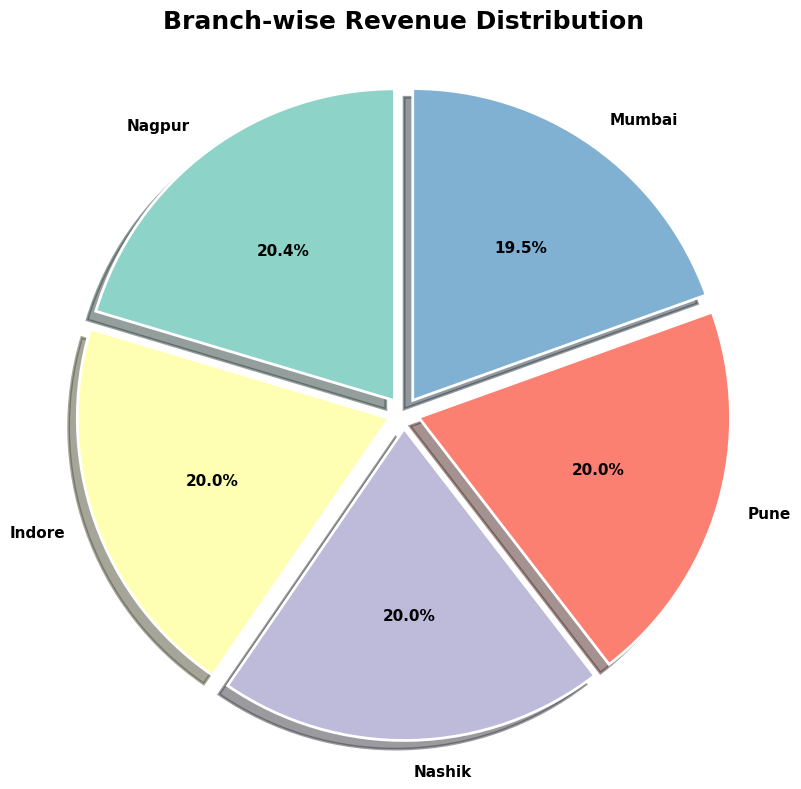

In [26]:
import matplotlib.pyplot as plt

# Revenue by Branch
branch = df.groupby('Branch')['Revenue'].sum().sort_values(ascending=False)

# Colors
colors = plt.cm.Set3.colors

plt.figure(figsize=(8, 8))

plt.pie(
    branch,
    labels=branch.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=[0.05] * len(branch),      # Slightly separate slices
    shadow=True,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 2
    },
    textprops={
        'fontsize': 11,
        'fontweight': 'bold'
    }
)

plt.title(
    'Branch-wise Revenue Distribution',
    fontsize=18,
    fontweight='bold',
    pad=20
)

# Makes the pie perfectly circular
plt.axis('equal')

plt.tight_layout()
plt.show()

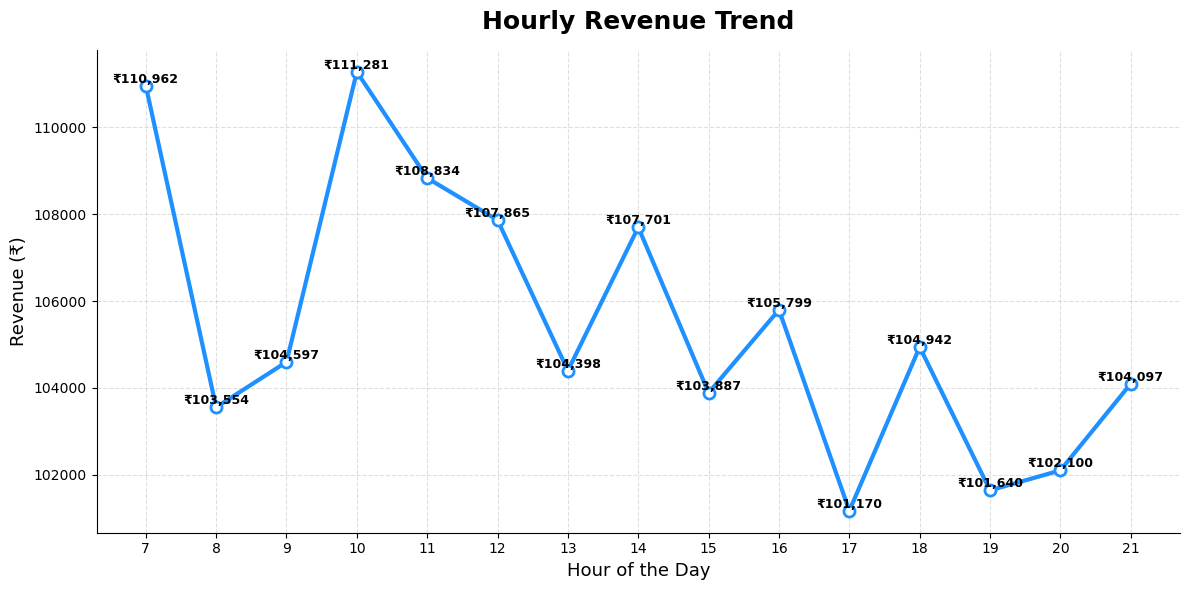

In [27]:
import matplotlib.pyplot as plt

# Revenue by Hour
hour = df.groupby('Hour')['Revenue'].sum().sort_index()

plt.figure(figsize=(12, 6))

plt.plot(
    hour.index,
    hour.values,
    color='dodgerblue',
    linewidth=3,
    marker='o',
    markersize=8,
    markerfacecolor='white',
    markeredgewidth=2
)

# Title and labels
plt.title('Hourly Revenue Trend', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Hour of the Day', fontsize=13)
plt.ylabel('Revenue (₹)', fontsize=13)

# Grid
plt.grid(True, linestyle='--', alpha=0.4)

# Remove unnecessary borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Display revenue values
for x, y in zip(hour.index, hour.values):
    plt.text(
        x,
        y,
        f'₹{y:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# Show every hour on x-axis
plt.xticks(hour.index)

plt.tight_layout()
plt.show()

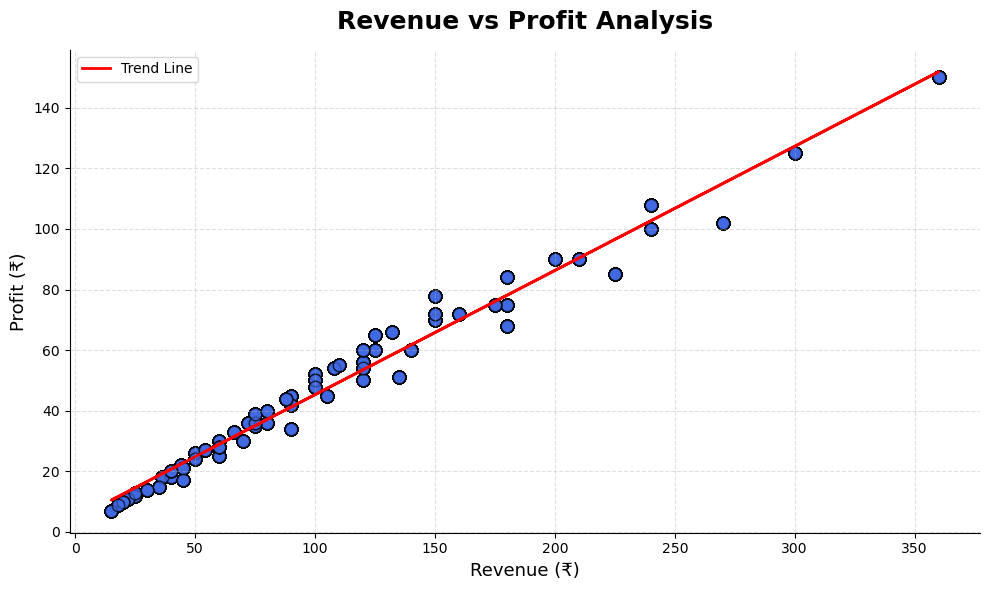

In [29]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Scatter plot
plt.scatter(
    df['Revenue'],
    df['Profit'],
    color='royalblue',
    edgecolor='black',
    s=80,
    alpha=0.7
)

# Best-fit (trend) line
z = np.polyfit(df['Revenue'], df['Profit'], 1)
p = np.poly1d(z)

plt.plot(
    df['Revenue'],
    p(df['Revenue']),
    color='red',
    linewidth=2,
    label='Trend Line'
)

# Title and labels
plt.title("Revenue vs Profit Analysis", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Revenue (₹)", fontsize=13)
plt.ylabel("Profit (₹)", fontsize=13)

# Grid
plt.grid(True, linestyle='--', alpha=0.4)

# Remove unnecessary borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
plt.legend()

plt.tight_layout()
plt.show()

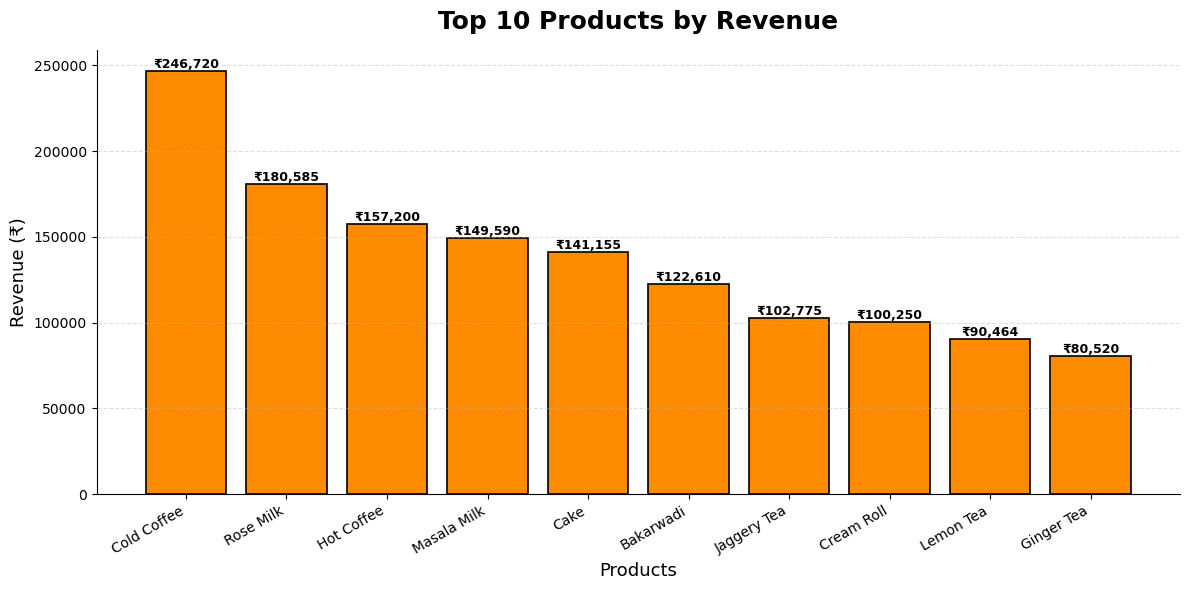

In [30]:
import matplotlib.pyplot as plt

# Top 10 Products by Revenue
top = (
    df.groupby('Product')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    top.index,
    top.values,
    color='darkorange',
    edgecolor='black',
    linewidth=1.2
)

# Title and labels
plt.title('Top 10 Products by Revenue', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Products', fontsize=13)
plt.ylabel('Revenue (₹)', fontsize=13)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Remove top and right borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Rotate x-axis labels
plt.xticks(rotation=30, ha='right')

# Add revenue labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'₹{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

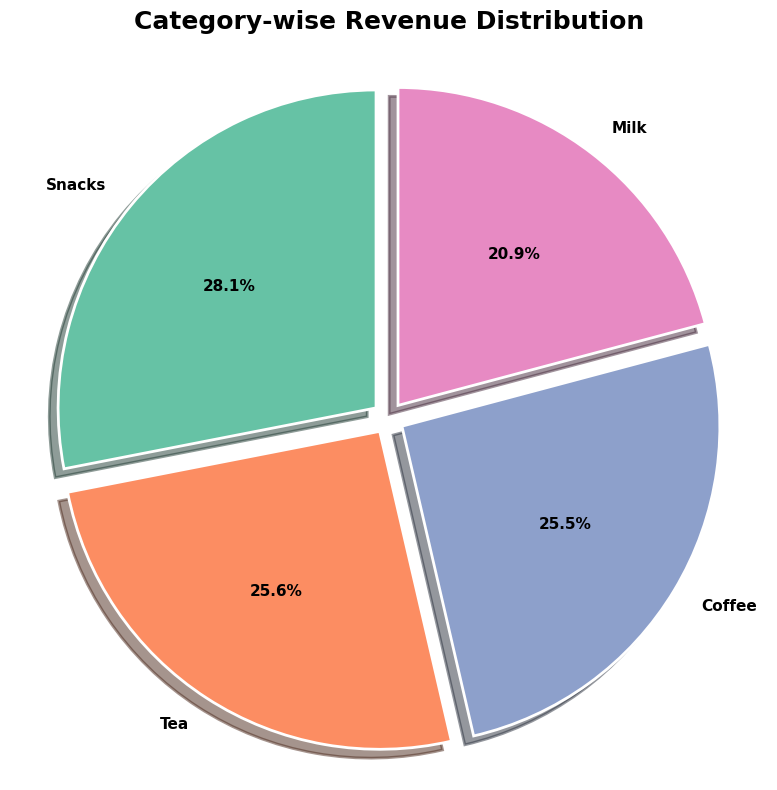

In [31]:
import matplotlib.pyplot as plt

# Revenue by Category
category = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 8))

colors = plt.cm.Set2.colors

plt.pie(
    category.values,
    labels=category.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05] * len(category),
    colors=colors,
    shadow=True,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 2
    },
    textprops={
        'fontsize': 11,
        'fontweight': 'bold'
    }
)

plt.title(
    'Category-wise Revenue Distribution',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.axis('equal')
plt.tight_layout()
plt.show()

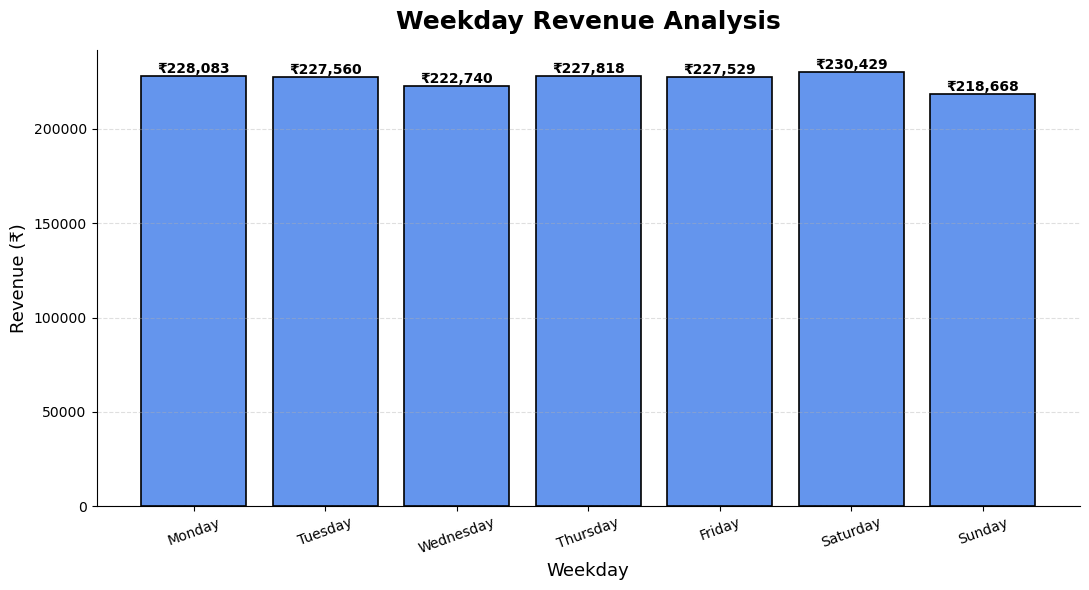

In [32]:
import matplotlib.pyplot as plt

# Arrange weekdays in correct order
weekday_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

weekday = (
    df.groupby('Weekday')['Revenue']
      .sum()
      .reindex(weekday_order)
)

plt.figure(figsize=(11, 6))

bars = plt.bar(
    weekday.index,
    weekday.values,
    color='cornflowerblue',
    edgecolor='black',
    linewidth=1.2
)

# Title and labels
plt.title(
    'Weekday Revenue Analysis',
    fontsize=18,
    fontweight='bold',
    pad=15
)
plt.xlabel('Weekday', fontsize=13)
plt.ylabel('Revenue (₹)', fontsize=13)

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Remove unnecessary borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Rotate labels slightly
plt.xticks(rotation=20)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'₹{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()